In [1]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np
import matplotlib as mpl
import pandas as pd
import torch
import json
import sys
import os
from glob import glob
import h5py
mpl.rcParams['pdf.fonttype'] = 42
# mpl.rcParams['font.family'] = 'serif'
# mpl.rcParams['font.serif'] = 'Times New Roman'
mpl.rcParams['font.size'] = 9


from sample_factory.utils.utils import log

In [2]:
rootpath = "/home/schaffert/Documents/Hippodunk/sample-factory/online_data_telemetry/InternalReward060/"
# experiment_name = "00_InternalReward01_see_11/"
# experiment_name = "01_InternalReward01_see_22/"
# experiment_name = "02_InternalReward01_see_333/"
# experiment_name = "00_InternalReward01_see_11/"
# experiment_name = "00_InternalReward01_see_11/"
# experiment_name = "00_InternalReward04_see_11/"
# experiment_name = "01_InternalReward04_see_22/"
# experiment_name = "02_InternalReward04_see_333/"
# experiment_name = "03_InternalReward04_see_4444/"
# experiment_name = "04_InternalReward04_see_55555/"
experiment_name = "00_InternalReward06_see_12/"
# experiment_name = "01_InternalReward06_see_23/"
# experiment_name = "02_InternalReward06_see_34/"
# experiment_name = "03_InternalReward06_see_45/"
telemetry_list_csv = glob(str(rootpath + experiment_name + "telemetry/*.csv"))
telemetry_list_h5 = glob(str(rootpath + experiment_name + "telemetry/*.h5"))
print(telemetry_list_csv)

['/home/schaffert/Documents/Hippodunk/sample-factory/online_data_telemetry/InternalReward060/00_InternalReward06_see_12/telemetry/pose_20251024_142012.csv']


In [3]:
pddata = pd.read_csv(telemetry_list_csv[0])
with h5py.File(telemetry_list_h5[0]) as h5:
    activations = {k: h5[k][...] for k in h5}

In [4]:
pddata

,frame,agent,x,y,z,rot_x,rot_y,rot_z,num_traj,info
0,0,0,772.093750,1841.382080,25.125,0.0,-30.388184,0.0,0,"{""num_frames"": 8}"
1,1,0,809.464905,1819.883911,25.125,0.0,-47.285156,0.0,0,"{""num_frames"": 8}"
2,2,0,841.413940,1791.223267,25.125,0.0,-64.176636,0.0,0,"{""num_frames"": 8}"
3,3,0,864.860107,1755.878906,25.125,0.0,-81.073608,0.0,0,"{""num_frames"": 8}"
4,4,0,878.048645,1714.280884,25.125,0.0,-97.970581,0.0,0,"{""num_frames"": 8}"
...,...,...,...,...,...,...,...,...,...,...
49996,49996,0,304.202942,381.227631,25.125,0.0,-25.878296,0.0,60,"{""num_frames"": 8}"
49997,49997,0,346.621185,369.396820,25.125,0.0,-42.775269,0.0,60,"{""num_frames"": 8}"
49998,49998,0,382.613007,346.028076,25.125,0.0,-59.666748,0.0,60,"{""num_frames"": 8}"
49999,49999,0,410.115021,313.182098,25.125,0.0,-76.563721,0.0,60,"{""num_frames"": 8}"


In [5]:
encoder_output = activations['encoder.DG_projection.linear']
encoder_output.shape

(50001, 16)

In [8]:
hippo_n_feature = 16
length = 71

In [17]:
pddata['rot_pi']=pddata['rot_y']*np.pi/180

In [18]:
tmp_act=activations
sids=tmp_act['core'][:,:-13:length]


xbound=(100,2000)
ybound=(100,2000)
grain = 19
occu_xy=np.histogramdd((pddata['x'],
                         pddata['y']),
                         (np.linspace(*xbound,grain+1),np.linspace(*ybound,grain+1)),
                         density=False)[0]




grain=19
seq0_xya=np.zeros((grain,grain,hippo_n_feature))
for i in range(hippo_n_feature):
    print(i)
    seq0_xya[:,:,i]=np.histogramdd((pddata['x'],
                                      pddata['y']),
                                      (np.linspace(*xbound,grain+1),np.linspace(*ybound,grain+1)),
                                      weights=sids[:,i],
                                      density=False)[0]

Hippo_L = 71
seqall_xya=np.zeros((grain,grain,12,16*Hippo_L))
for i in range(16*Hippo_L):
    seqall_xya[:,:,:,i]=np.histogramdd((pddata['x'],pddata['y'],pddata['rot_pi']),(np.linspace(*xbound,grain+1),np.linspace(*ybound,grain+1),np.linspace(-np.pi,np.pi,13)),weights=tmp_act['core'][:,i],density=False)[0]


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15


In [10]:
seq0_xya.shape

(19, 19, 16)

In [7]:
import numpy as np

def compute_correlation_kernel(X, max_dx=5, max_dy=5, demean=True):
    """
    Computes a spatial correlation kernel from a 3D array X (H, W, F).
    
    Parameters:
        X: ndarray of shape (H, W, F)
        max_dx, max_dy: maximum spatial shifts in x and y
        demean: if True, subtract mean and normalize variance (z-score)
        
    Returns:
        kernel: 2D array of shape (2*max_dx+1, 2*max_dy+1) containing average correlation.
    """
    H, W, F = X.shape
    kernel = np.full((2 * max_dx + 1, 2 * max_dy + 1), np.nan)

    if demean:
        X = (X - X.mean(axis=2, keepdims=True)) / (X.std(axis=2, keepdims=True) + 1e-8)
    
    for dx in range(-max_dx, max_dx + 1):
        for dy in range(-max_dy, max_dy + 1):
            x1s, x1e = max(0, -dx), min(H, H - dx)
            y1s, y1e = max(0, -dy), min(W, W - dy)

            A = X[x1s:x1e, y1s:y1e]
            B = X[x1s + dx:x1e + dx, y1s + dy:y1e + dy]

            if demean:
                # z-scored → Pearson correlation is just dot product
                corr = np.sum(A * B, axis=-1) / F
            else:
                # use cosine similarity: (A·B) / (||A|| * ||B||)
                A_norm = np.linalg.norm(A, axis=-1)
                B_norm = np.linalg.norm(B, axis=-1)
                dot = np.sum(A * B, axis=-1)
                corr = dot / (A_norm * B_norm + 1e-8)

            kernel[dx + max_dx, dy + max_dy] = np.nanmean(corr)

    return kernel

In [12]:
xygrain=19

In [ ]:

Spatial_kernel=dict()
for key in PFs_enjoys[0]:
    tmpPFs_enjoys=np.array([x[key] for x in PFs_enjoys])
    # tmpPFs_enjoys=tmpPFs_enjoys.reshape(tmpPFs_enjoys.shape[0],-1,tmpPFs_enjoys.shape[-1])
    tmp_kernels=np.zeros((8,2*xygrain-1,2*xygrain-1))
    for epoch in range(8):
        tmp=tmpPFs_enjoys[epoch,:,:,:]

        tmp_kernels[epoch,:,:]=compute_correlation_kernel(tmp, max_dx=xygrain-1, max_dy=xygrain-1)
    Spatial_kernel[key]=tmp_kernels
    #     for i in range(xygrain):
    #         for j in range(xygrain):
    #             tmp_kernels[epoch,i,j]=np.array([pd.DataFrame(tmp[i,j]).corr()

    # np.array([pd.DataFrame(tmpPFs_enjoys[:,i,:].T).corr() for i in range(tmpPFs_enjoys.shape[1])])

In [13]:
tmp = seq0_xya
tmp_kernel=compute_correlation_kernel(tmp, max_dx=xygrain-1, max_dy=xygrain-1)

/tmp/ipykernel_383728/2358332669.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.96, 1],pad=0.01)


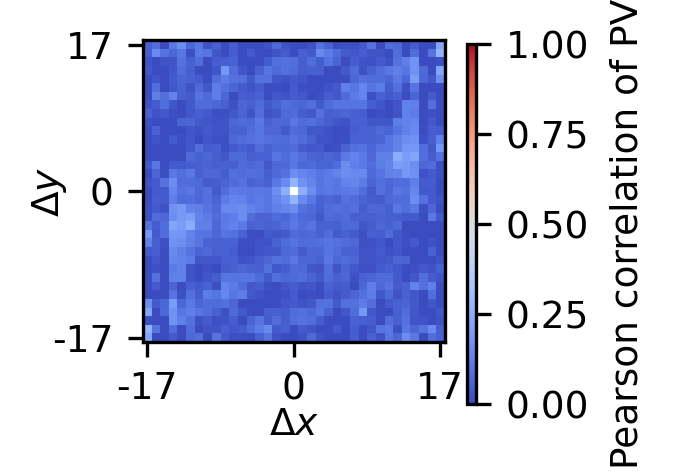

In [19]:
# layer_names = list(Spatial_kernel.keys())
# n_layers = len(layer_names)
# n_epochs = 8

# Create the grid of axes
fig, ax = plt.subplots(1, 1,
                       figsize=(1.5, 1.5),
                       dpi=300,
                       constrained_layout=False)

tmp = tmp_kernel.copy()
tmp[xygrain-1, xygrain-1] = np.nan
im = ax.imshow(
    tmp[1:-1, 1:-1],
    origin='lower',
    vmin=0, vmax=1,
    cmap='coolwarm'
)
ax.set_axis_off()
# ax[i,0].text(-30,15,displayname_dict[key],rotation=90,va='center',ha='center',fontsize=9)
# # Left‐side row label
# ax[i, 0].set_axis_on()
# ax[i, 0].set_ylabel(key, rotation=0, labelpad=40, va='center')

# Bottom‐left only: set tick‐labels and axis on
ax.set_axis_on()
ticks = np.arange(0, xygrain*2-3, xygrain-2)
labels = ticks - xygrain + 2
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)
ax.set_xlabel(r'$\Delta x$',labelpad=0)
ax.set_ylabel(r'$\Delta y$',labelpad=-4)

# # Column titles
# for j in range(n_epochs):
#     # title = f"Epoch {j}" if j < n_epochs-1 else "Epoch new"
#     title = j
#     ax[0, j].set_title(title, pad=6, fontsize=9)
# ax[0,0].set_title('Epoch 0', pad=6, fontsize=9)
# ax[0,-1].set_title('new', pad=6, fontsize=9)

# Add a single horizontal colorbar below all subplots
# Use the last image handle 'im' for the color mapping
cax=fig.add_axes([0.97, 0.13, 0.02, 0.80])  # [left, bottom, width, height]
cbar = fig.colorbar(
    im,
    cax=cax,
    ax=ax,
    orientation='vertical',
    fraction=0.05,  # width of colorbar as fraction of total width
    pad=0.08        # space between subplots and colorbar
)
cbar.set_label('Pearson correlation of PVs', labelpad=5)

# Adjust layout so labels/colorbar aren't clipped
fig.tight_layout(rect=[0, 0, 0.96, 1],pad=0.01)
# fig.tight_layout(pad=0.2)
# Save
# fig.savefig(current_fig_path/"correlation_kernel.pdf",
            # dpi=300,
            # bbox_inches='tight')

In [21]:
seqall_xya.shape

(19, 19, 12, 1136)

In [27]:
tmp = np.nansum(seqall_xya, 2)
tmp_kernel_CA3=compute_correlation_kernel(tmp, max_dx=xygrain-1, max_dy=xygrain-1)

/tmp/ipykernel_383728/2786497168.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.96, 1],pad=0.01)


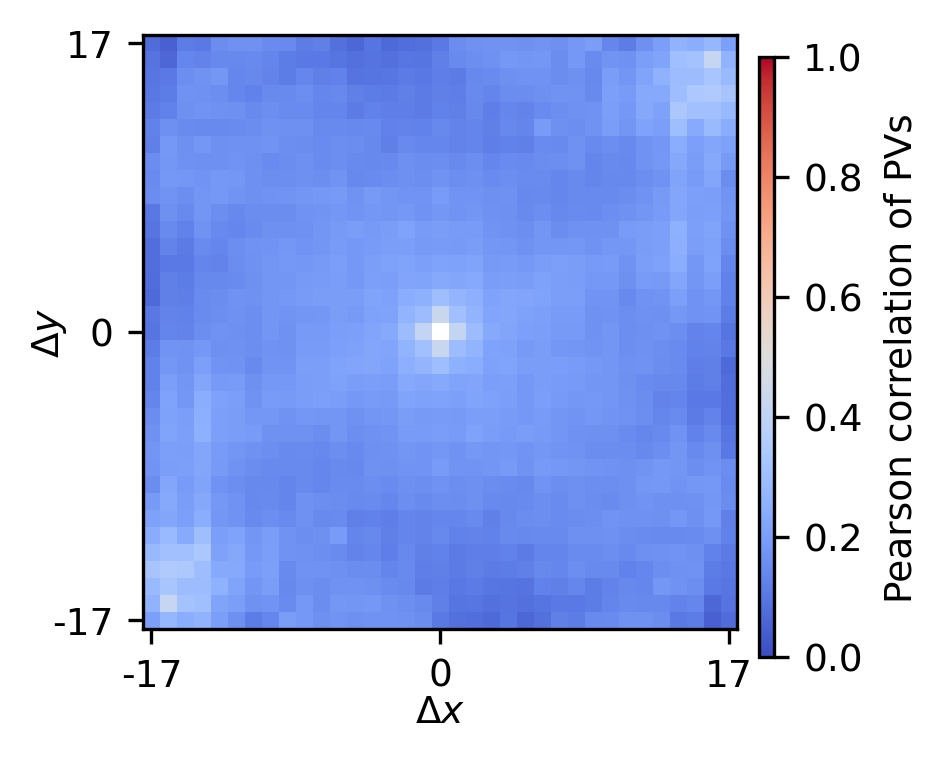

In [28]:
# layer_names = list(Spatial_kernel.keys())
# n_layers = len(layer_names)
# n_epochs = 8

# Create the grid of axes
fig, ax = plt.subplots(1, 1,
                       figsize=(2.5, 2.5),
                       dpi=300,
                       constrained_layout=False)

tmp = tmp_kernel_CA3.copy()
tmp[xygrain-1, xygrain-1] = np.nan
im = ax.imshow(
    tmp[1:-1, 1:-1],
    origin='lower',
    vmin=0, vmax=1,
    cmap='coolwarm'
)
ax.set_axis_off()
# ax[i,0].text(-30,15,displayname_dict[key],rotation=90,va='center',ha='center',fontsize=9)
# # Left‐side row label
# ax[i, 0].set_axis_on()
# ax[i, 0].set_ylabel(key, rotation=0, labelpad=40, va='center')

# Bottom‐left only: set tick‐labels and axis on
ax.set_axis_on()
ticks = np.arange(0, xygrain*2-3, xygrain-2)
labels = ticks - xygrain + 2
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)
ax.set_xlabel(r'$\Delta x$',labelpad=0)
ax.set_ylabel(r'$\Delta y$',labelpad=-4)

# # Column titles
# for j in range(n_epochs):
#     # title = f"Epoch {j}" if j < n_epochs-1 else "Epoch new"
#     title = j
#     ax[0, j].set_title(title, pad=6, fontsize=9)
# ax[0,0].set_title('Epoch 0', pad=6, fontsize=9)
# ax[0,-1].set_title('new', pad=6, fontsize=9)

# Add a single horizontal colorbar below all subplots
# Use the last image handle 'im' for the color mapping
cax=fig.add_axes([0.97, 0.13, 0.02, 0.80])  # [left, bottom, width, height]
cbar = fig.colorbar(
    im,
    cax=cax,
    ax=ax,
    orientation='vertical',
    fraction=0.05,  # width of colorbar as fraction of total width
    pad=0.08        # space between subplots and colorbar
)
cbar.set_label('Pearson correlation of PVs', labelpad=5)

# Adjust layout so labels/colorbar aren't clipped
fig.tight_layout(rect=[0, 0, 0.96, 1],pad=0.01)
# fig.tight_layout(pad=0.2)
# Save
# fig.savefig(current_fig_path/"correlation_kernel.pdf",
            # dpi=300,
            # bbox_inches='tight')